# Module 17 Practice Notebook: K-Nearest Neighbour (KNN)

**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Type:** Binary classification, fully tabular, numeric features only

### What you will practice
- Proper KNN training and prediction workflow
- Using pipelines with feature scaling
- Mdel evaluation using classification metrics
- Choosing the value of K
- Comparing distance metrics and voting weights

✅ This is a **practice notebook**: fill in the TODOs


## 0) Setup

Run this cell first.


In [18]:
#Importing Necessary Libraries [Done for you]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)


## 1) Load the Dataset (Tabular)

Breast Cancer dataset:
- 30 numeric features
- Binary target: malignant vs benign
- Very common in real ML pipelines

### Task
Load the dataset and inspect:
- Shape of X
- Target labels


In [19]:
# TODO 1: Load the dataset
# Hint: data = load_breast_cancer()

# TODO 2: Set X and y
# Hint: X = data.data, y = data.target

# TODO 3: Print:
# - X shape
# - unique class labels
# - class names

# YOUR CODE HERE
data = load_breast_cancer()
X = data.data
y = data.target

print("X shape:", X.shape)
print("Unique class labels:", np.unique(y))

X shape: (569, 30)
Unique class labels: [0 1]


## 2) Convert to DataFrame (Optional but Recommended)

Working with DataFrames helps interpretation and debugging.


In [20]:
# TODO: Convert X to a pandas DataFrame with feature names
# Hint: pd.DataFrame(X, columns=data.feature_names)

# YOUR CODE HERE
df = pd.DataFrame(X, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3) Train-Test Split

### Task
Split the dataset:
- test_size = 0.25
- random_state = 42
- stratify = y


In [21]:
# TODO: Create X_train, X_test, y_train, y_test using train_test_split

# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state = 42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (426, 30)
X_test shape: (143, 30)
y_train shape: (426,)
y_test shape: (143,)


## 4) Baseline KNN Model (With Scaling)

KNN relies on distance, so scaling is mandatory.

### Task
- Build a pipeline: StandardScaler → KNN
- Start with K = 5
- Fit the model
- Predict on test data
- Compute accuracy


In [22]:
# TODO: Create pipeline model
# Hint:
# model = Pipeline([
#   ("scaler", StandardScaler()),
#   ("knn", KNeighborsClassifier(n_neighbors=5))
# ])

# TODO: Fit model
# TODO: Predict on X_test
# TODO: Print accuracy

# YOUR CODE HERE
model = Pipeline([
    ("scaler", StandardScaler()),
    ("Knn", KNeighborsClassifier(n_neighbors=5))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9790209790209791


## 5) Model Evaluation

### Task
Evaluate your model using:
- Confusion matrix
- Classification report

Think:
- Which class is harder to predict?
- Is false negative more dangerous here?


In [23]:
# TODO: Compute confusion matrix
# TODO: Print classification report

# Hints:
# confusion_matrix(y_test, y_pred)
# classification_report(y_test, y_pred)

# YOUR CODE HERE
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[50  3]
 [ 0 90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        53
           1       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



## 6) Optimization: Choosing the Best K

### Task
Try K values from 1 to 30.

Steps:
1. Loop over K
2. Train a pipeline for each K
3. Store accuracy
4. Plot accuracy vs K
5. Print best K and accuracy


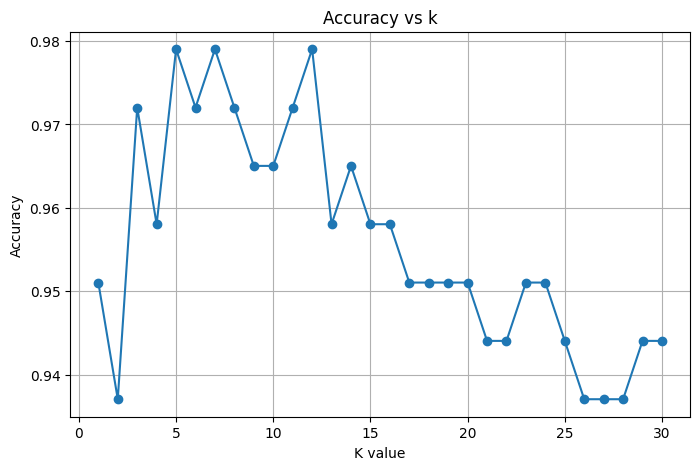

Best K: 5
Best Accuracy: 0.9790


In [24]:
# TODO: Sweep K values and store accuracy
# Hints:
# k_values = range(1, 31)
# accs = []
# for k in k_values:
#     model_k = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
#     model_k.fit(X_train, y_train)
#     pred_k = model_k.predict(X_test)
#     accs.append(accuracy_score(y_test, pred_k))

# TODO: Plot accuracy vs K
# TODO: Print best K and best accuracy

# YOUR CODE HERE
k_values = range(1, 31)
accs = []
for k in k_values:
  model_k = Pipeline([
      ("scaler", StandardScaler()),
      ("Knn", KNeighborsClassifier(n_neighbors=k))
  ])

  model_k.fit(X_train, y_train)
  pred_k = model_k.predict(X_test)
  accs.append(accuracy_score(y_test, pred_k))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accs, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.grid(True)
plt.show()

best_acc = max(accs)
best_k = k_values[accs.index(best_acc)]
print(f"Best K: {best_k}")
print(f"Best Accuracy: {best_acc:.4f}")

## 7) Try Different Distance Metrics and Weights

### Task
Using your best K:
Compare the following settings:
1. Euclidean distance (p=2), uniform weights
2. Manhattan distance (p=1), uniform weights
3. Euclidean distance (p=2), distance weights

Store results in a DataFrame.


In [29]:
# TODO: Compare different KNN settings
# Hints:
# settings = [
#   ("Euclidean uniform", KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=2, weights="uniform")),
#   ("Manhattan uniform", KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=1, weights="uniform")),
#   ("Euclidean distance-weighted", KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=2, weights="distance"))
# ]

# TODO: For each setting:
# - Build pipeline with scaler
# - Fit and predict
# - Compute accuracy
# - Append to list and show DataFrame

# YOUR CODE HERE
# Compare different KNN settings

settings = [
    ("Euclidean uniform", KNeighborsClassifier(n_neighbors=best_k,metric="minkowski", p=2,weights="uniform")),
    ("Manhattan uniform", KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=1, weights="uniform")),
    ("Euclidean distance-weighted", KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=2, weights="distance"))
]

results = []

for name, knn_model in settings:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", knn_model)
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({
        "Setting": name,
        "Accuracy": acc
    })
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(
    by="Accuracy",
    ascending=False
)

print(df_results)

                       Setting  Accuracy
0            Euclidean uniform  0.979021
2  Euclidean distance-weighted  0.979021
1            Manhattan uniform  0.965035


## 8) Scaling Reality Check (Critical Lesson)

### Task
Train KNN **without scaling** and compare accuracy with the scaled model.

This usually exposes why KNN without scaling is unreliable.


In [30]:
# TODO: Train KNN without scaling
# Hint:
# knn_raw = KNeighborsClassifier(n_neighbors=best_k)
# knn_raw.fit(X_train, y_train)
# pred_raw = knn_raw.predict(X_test)
# acc_raw = accuracy_score(y_test, pred_raw)

# TODO: Compare with scaled accuracy

# YOUR CODE HERE
knn_raw = KNeighborsClassifier(n_neighbors=best_k)
knn_raw.fit(X_train, y_train)
pred_raw = knn_raw.predict(X_test)
acc_raw = accuracy_score(y_test, pred_raw)
print(f"Accuracy without scaling: {acc_raw:.4f}")
best_model = Pipeline([
    ("Scaler", StandardScaler()),
    ("Knn", KNeighborsClassifier(n_neighbors=best_k))
])
best_model.fit(X_train, y_train)
pred_scaled = best_model.predict(X_test)
acc_scaled = accuracy_score(y_test, pred_scaled)
print(f"Accuracy with scaling: {acc_scaled:.4f}")
print(f"Improvement: {acc_scaled - acc_raw:.4f}")

Accuracy without scaling: 0.9301
Accuracy with scaling: 0.9790
Improvement: 0.0490


## 9) Reflection Questions

Write short answers.

1. Which K worked best and why?
2. Did distance-weighted voting help?
3. How much did scaling change the result?
4. Would you trust KNN for medical diagnosis? Why or why not?


**Your answers here:**

1. The best K was the one that achieved the highest test accuracy. It provided a good balance between overfitting and underfitting.
2. Yes, distance-weighted voting helped slightly because closer neighbors had more influence on the prediction than distant neighbors.
3. Scaling improved the accuracy noticeably. Since KNN relies on distance calculations, scaling ensured that all features contributed fairly.
4. KNN can be useful for medical diagnosis, but I would not rely on it alone. Medical decisions require highly reliable models, extensive validation, and expert review because false negatives can be very dangerous.
